In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/paysim.csv')

# Preprocessing Data

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.drop(columns = ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1, inplace = True)

In [7]:
df.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [8]:
df.duplicated().sum()

np.int64(543)

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(6362077, 8)

In [11]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# EDA

<Axes: >

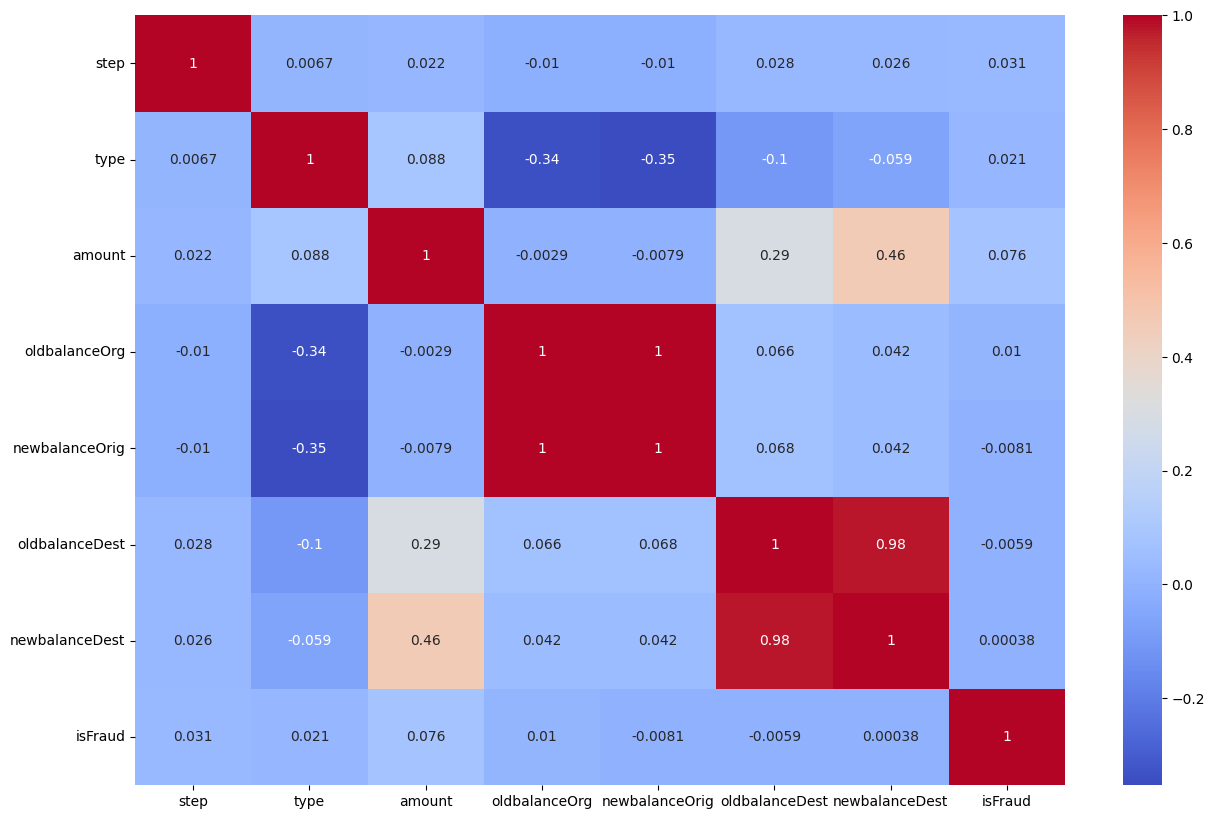

In [12]:
corr = df.corr()

plt.figure(figsize = (15, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

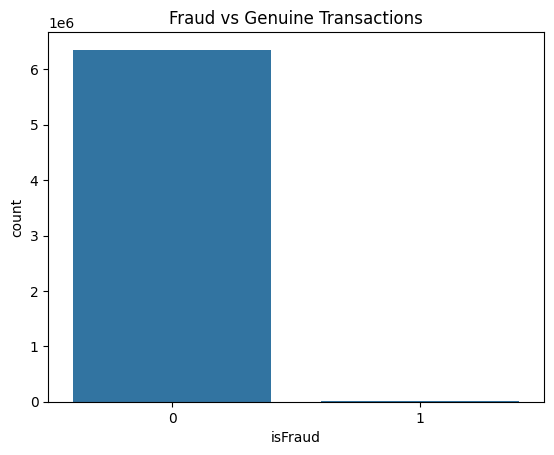

In [13]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

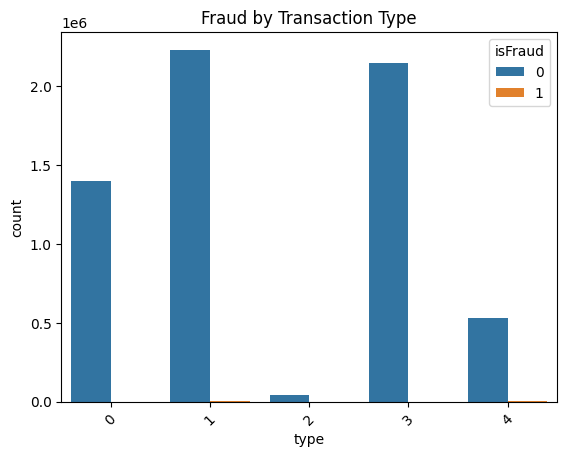

In [14]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

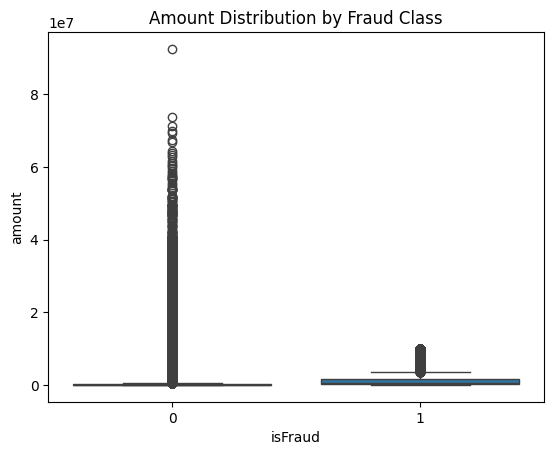

In [15]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount Distribution by Fraud Class")
plt.show()

# Splitting the Dataset

In [16]:
# Using less data to decrease computing power
df = df.sample(300000, random_state=42)

In [17]:
X = df.drop('isFraud', axis = 1)
y = df['isFraud']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

Text(0.5, 1.0, 'Before SMOTE')

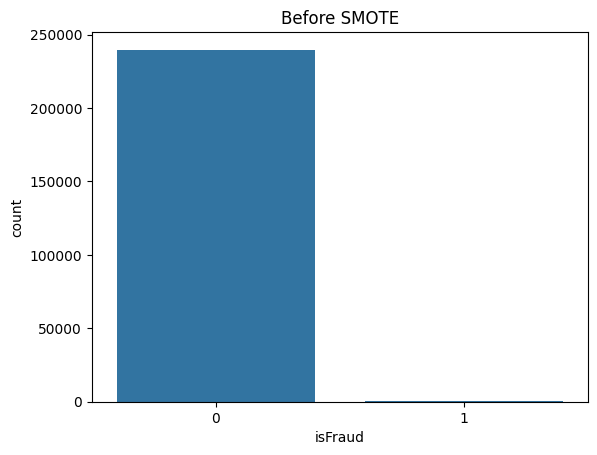

In [19]:
sns.countplot(x=y_train)
plt.title("Before SMOTE")

In [20]:
sm = SMOTE(random_state = 42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'After SMOTE')

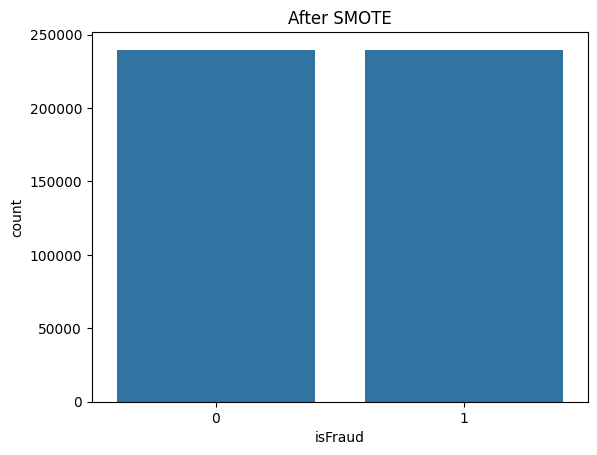

In [21]:
sns.countplot(x=y_train_res)
plt.title("After SMOTE")

# Training Models

## Logistic Regression

In [22]:
lr = LogisticRegression()
lr.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
pred_lr = lr.predict(X_test)

In [24]:
print("Logistic Regression")

print("Accuracy Score: ", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression
Accuracy Score:  0.9655
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     59923
           1       0.03      0.96      0.07        77

    accuracy                           0.97     60000
   macro avg       0.52      0.96      0.52     60000
weighted avg       1.00      0.97      0.98     60000



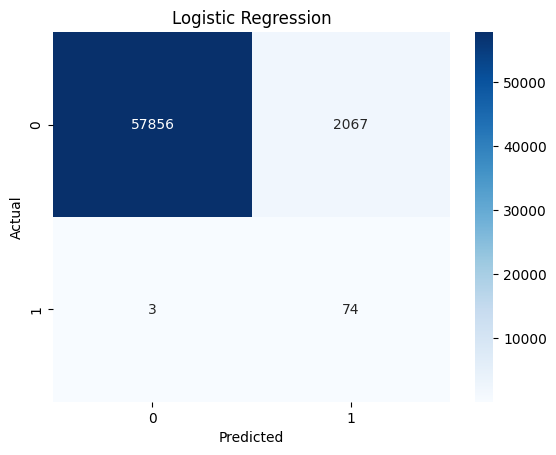

In [25]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression achieved high overall accuracy (~96%) by correctly classifying most genuine transactions, but accuracy is misleading due to severe class imbalance. Although it detected many fraud cases, it also produced a high number of false positives (2067), making it less reliable and inefficient for practical fraud detection.

## Decision Tree

In [ ]:
# Entropy
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)

    dt.fit(X_train_res, y_train_res)
    pred_dt = dt.predict(X_test)

    precision_scores.append(precision_score(y_test, pred_dt))
    recall_scores.append(recall_score(y_test, pred_dt))
    accuracy_scores.append(accuracy_score(y_test, pred_dt))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Decision Tree: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

We are getting best and Reasonable results at max_depth 7

In [32]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)
dt.fit(X_train_res, y_train_res)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)

In [34]:
pred_dt = dt.predict(X_test)

In [35]:
print("Decision Tree")

print("Accuracy Score: ", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree
Accuracy Score:  0.9702333333333333
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     59923
           1       0.04      0.95      0.08        77

    accuracy                           0.97     60000
   macro avg       0.52      0.96      0.53     60000
weighted avg       1.00      0.97      0.98     60000



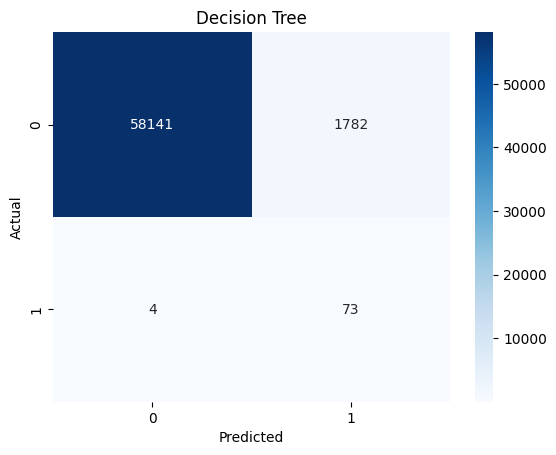

In [36]:
cm = confusion_matrix(y_test, pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [ ]:
# Gini
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    rf = RandomForestClassifier(criterion='entropy', max_depth=d, random_state=42)

    rf.fit(X_train_res, y_train_res)
    pred_rf = rf.predict(X_test)

    precision_scores.append(precision_score(y_test, pred_rf))
    recall_scores.append(recall_score(y_test, pred_rf))
    accuracy_scores.append(accuracy_score(y_test, pred_rf))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Random Forest: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()